# Calderon Problem

Authored by Xianjin Yang

In [ ]:
from pyKoLesky.ordering import maximin
from pyKoLesky.cholesky import sparsity_pattern,sparse_cholesky,non_zeros
import torch
import torch.nn as nn
import torch.optim as optim
import time
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Using device:", device)

torch.set_default_dtype(torch.float64)

# Parameters
N = 9  # Number of grid points
L = 1.0  # Length of the domain [0, 1]
rho = 100  # Sparsity factor defined by ln(N/epsilon)
num_newton_iter = 10  # Number of classical Newton iterations for Data generation
num_realizations = 1000  # Number of realizations
num_training = num_realizations * num_newton_iter - 2500  # Number of training samples
num_folds = 5  # For cross-validation

# Create 2D grid
x = torch.linspace(0, L, N + 1, device=device)[:-1]  # shape (N,)
y = torch.linspace(0, L, N + 1, device=device)[:-1]  # shape (N,)

X, Y = torch.meshgrid(x, y, indexing='ij')  # X,Y are N x N tensors
dx = x[1] - x[0]  # Grid spacing
X_coords = torch.stack([X.flatten(), Y.flatten()], dim=1)  #  Flatten coordinates, shape (N*N, 2)

# Sparsity pattern
Perm, lengths = maximin(X_coords)  # Calculating MaxMin Ordering
sparsity = sparsity_pattern(X_coords[Perm], lengths, rho)  # Calculating the sparsity pattern
nonzeros_indices = non_zeros(N*N, sparsity)  # Calculating the non zero indices


# Gaussian Process class with learnable nugget
class GaussianProcess(nn.Module):
    def __init__(self, length_scale=1.0, nugget_init=1e-6, nu=3 / 2):
        super(GaussianProcess, self).__init__()
        self.length_scale = nn.Parameter(torch.ones(N*N) * length_scale)
        # self.length_scale = nn.Parameter(torch.ones(1) * length_scale)
        # self.nugget = nn.Parameter(torch.tensor(nugget_init))
        self.nugget = torch.tensor(nugget_init)
        self.nu = nu

    def matern_kernel(self, X1, X2):
        # Compute pairwise Euclidean distance between points in scaled X1 and X2
        X1_scaled = X1 * self.length_scale
        X2_scaled = X2 * self.length_scale
        pairwise_dists = torch.cdist(X1_scaled, X2_scaled, p=2)

        if self.nu == 3 / 2:
            scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists
            K = (1 + scale) * torch.exp(-scale)
        else:
            raise ValueError("Only nu=3/2 is supported.")
        return K

    def fit(self, X_train, y_train):
        # Kernel matrices with learnable nugget
        K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
        # L = torch.linalg.cholesky(K_train)
        # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
        alpha_train = torch.linalg.solve(K_train, y_train)
        self.alpha_train = alpha_train
        self.X_train = X_train

    def forward(self, X_val):
        K_val_train = self.matern_kernel(X_val, self.X_train)
        y_pred_val = K_val_train @ self.alpha_train
        return y_pred_val


# Generate the covariance matrix using the Matérn kernel
def generate_covariance_matrix(kernel_func, x, length_scale):
    return kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)


def generate_f_u_from_gp(
    num_realizations: int,
    N: int,
    kernel_func,
    length_scale: float
):
    """
    Generate:
      - f: of shape (num_realizations, 16*(N-1)^2)
      - u: of shape (num_realizations, N^2), with u > 0 by construction
        (exponentiating the GP samples).

    We build two separate index arrays x_f, x_u to form two covariance kernels:
      K_f for f, and K_u for u.

    Parameters
    ----------
    num_realizations : int
        Number of random samples to generate.
    N : int
        Grid size or parameter controlling the dimension.
    kernel_func : callable
        A function kernel_func(x1, x2, length_scale) -> Covariance matrix.
        Must handle x1, x2 of shape (M, 1) consistently.
    length_scale : float
        Length scale parameter for the kernel.

    Returns
    -------
    f_realizations : Tensor of shape (num_realizations, 16*(N-1)^2)
    u_realizations : Tensor of shape (num_realizations, N^2),
                     guaranteed positive by exponentiation.
    """

    # 1) Dimensions we want
    f_dim = N**2
    u_dim = N**2

    # 2) Create index arrays for each
    #    Here we just use arange(...) as a simple 1D "spatial" index
    x_f = torch.arange(f_dim, dtype=torch.double)
    x_u = torch.arange(u_dim, dtype=torch.double)

    # 3) Build covariance K_f for f
    K_f = kernel_func(x_f.unsqueeze(1), x_f.unsqueeze(1), length_scale)
    # Add a small diagonal jitter for numerical stability
    K_f = K_f + 1e-3 * torch.eye(f_dim, dtype=torch.double)
    L_f = torch.linalg.cholesky(K_f)  # shape: (f_dim, f_dim)

    # 4) Build covariance K_u for u
    K_u = kernel_func(x_u.unsqueeze(1), x_u.unsqueeze(1), length_scale)
    K_u = K_u + 1e-3 * torch.eye(u_dim, dtype=torch.double)
    L_u = torch.linalg.cholesky(K_u)  # shape: (u_dim, u_dim)

    # 5) Draw standard normal samples for f and u
    #    shape: (num_realizations, f_dim) and (num_realizations, u_dim)
    f_standard = torch.randn(num_realizations, f_dim, dtype=torch.double)
    u_standard = torch.randn(num_realizations, u_dim, dtype=torch.double)

    # 6) Correlate by applying Cholesky
    #    (L_f @ f_standard.T) => shape (f_dim, num_realizations)
    #    => transpose => (num_realizations, f_dim)
    f_realizations = (L_f @ f_standard.T).T
    u_realizations = (L_u @ u_standard.T).T

    # 7) Exponentiate u to ensure positivity
    u_realizations = torch.exp(u_realizations)
    f_tmp = torch.exp(f_realizations)
    f_realizations = torch.cat([(forward_map_gamma_to_flux(f_tmp[i, :])).unsqueeze(0)
                     for i in range(num_realizations)], dim=0)

    return f_realizations, u_realizations



def idx(i, j):
    return i * N + j


num_points = N * N
boundary_size = 4 * (N - 1)

# Create G on the GPU
G = torch.zeros((num_points, boundary_size), device=device)


# Bottom boundary (excluding corners)
j = torch.arange(1, N - 1, device=device)  # Excluding corners
b_idx = idx(0, j)
g_idx = j - 1 + 2 * (N - 1)
G[b_idx, g_idx] = 1.0

# Top boundary (excluding corners)
b_idx = idx(N - 1, j)
g_idx = j - 1 + 3 * (N - 1)
G[b_idx, g_idx] = 1.0

# Left boundary (excluding corners)
i = torch.arange(1, N - 1, device=device)  # Excluding corners
b_idx = idx(i, 0)
g_idx = i - 1
G[b_idx, g_idx] = 1.0

# Right boundary (excluding corners)
b_idx = idx(i, N - 1)
g_idx = i - 1 + (N - 1)
G[b_idx, g_idx] = 1.0

# Handle corners explicitly
G[idx(0, 0), 2 * (N - 1)] = 1.0  # Bottom-left corner
G[idx(0, N - 1), 2 * (N - 1) + (N - 2)] = 1.0  # Bottom-right corner
G[idx(N - 1, 0), 3 * (N - 1)] = 1.0  # Top-left corner
G[idx(N - 1, N - 1), 3 * (N - 1) + (N - 2)] = 1.0  # Top-right corner


def forward_map_gamma_to_flux(gamma_flat):
    """
    Compute the flattened product of flux_matrix and A_inverse without reshaping gamma.

    Parameters:
        N (int): Number of grid points per dimension (including boundary).
        L (float): Length of the domain [0, L] x [0, L].
        gamma_flat (tensor): Flattened conductivity tensor of shape (N^2,).

    Returns:
        flux_matrix_A_inv_flat (torch.Tensor): Flattened product of flux_matrix and A_inverse.
    """
    h = L / (N - 1)
    num_points = N * N
    A = torch.zeros((num_points, num_points), device=gamma_flat.device)


    # Reshape gamma_flat for 2D indexing
    gamma = gamma_flat.reshape(N, N)

    # Interior points (excluding boundaries)
    i, j = torch.meshgrid(torch.arange(1, N - 1), torch.arange(1, N - 1), indexing='ij')
    k = i * N + j  # Flattened indices for interior points

    # Compute gamma values for neighbors
    gamma_ip = (gamma[i + 1, j] + gamma[i, j]) / 2
    gamma_im = (gamma[i - 1, j] + gamma[i, j]) / 2
    gamma_jp = (gamma[i, j + 1] + gamma[i, j]) / 2
    gamma_jm = (gamma[i, j - 1] + gamma[i, j]) / 2

    # Fill in the A matrix for interior points
    A[k, k] = -(gamma_ip + gamma_im + gamma_jp + gamma_jm) / (h ** 2)
    A[k, k + N] = gamma_ip / (h ** 2)  # Below neighbor
    A[k, k - N] = gamma_im / (h ** 2)  # Above neighbor
    A[k, k + 1] = gamma_jp / (h ** 2)  # Right neighbor
    A[k, k - 1] = gamma_jm / (h ** 2)  # Left neighbor

    # Boundary points: Dirichlet condition (diagonal = 1.0)
    boundary_indices = torch.cat([
        torch.arange(0, N),  # Bottom boundary
        torch.arange(num_points - N, num_points),  # Top boundary
        torch.arange(0, num_points, N),  # Left boundary
        torch.arange(N - 1, num_points, N)  # Right boundary
    ])
    A[boundary_indices, boundary_indices] = 1.0
    
    # Creating the flux matrix
    flux_matrix = torch.zeros((4 * (N - 1), num_points), device=gamma_flat.device)

    # Bottom boundary (excluding corners)
    j = torch.arange(1, N - 1)
    row = j - 1 + 2 * (N - 1)
    center = j
    neighbor = N + j
    gamma_vals = gamma[0, j]
    flux_matrix[row, center] = -gamma_vals / h
    flux_matrix[row, neighbor] = gamma_vals / h

    # Top boundary (excluding corners)
    row = j - 1 + 3 * (N - 1)
    center = (N - 1) * N + j
    neighbor = (N - 2) * N + j
    gamma_vals = gamma[-1, j]
    flux_matrix[row, center] = gamma_vals / h
    flux_matrix[row, neighbor] = -gamma_vals / h

    # Left boundary (excluding corners)
    i = torch.arange(1, N - 1)
    row = i - 1
    center = i * N
    neighbor = i * N + 1
    gamma_vals = gamma[i, 0]
    flux_matrix[row, center] = -gamma_vals / h
    flux_matrix[row, neighbor] = gamma_vals / h

    # Right boundary (excluding corners)
    row = i - 1 + (N - 1)
    center = i * N + (N - 1)
    neighbor = i * N + (N - 2)
    gamma_vals = gamma[i, -1]
    flux_matrix[row, center] = gamma_vals / h
    flux_matrix[row, neighbor] = -gamma_vals / h

    # Handle corners
    bottom_left_corner = (gamma[0, 0] + gamma[0, 1]) / 2
    bottom_right_corner = (gamma[0, -1] + gamma[0, -2]) / 2
    top_left_corner = (gamma[-1, 0] + gamma[-2, 0]) / 2
    top_right_corner = (gamma[-1, -1] + gamma[-2, -2]) / 2

    # Bottom-left corner
    flux_matrix[0, 0] = -bottom_left_corner / h
    flux_matrix[0, N] = bottom_left_corner / h

    # Bottom-right corner
    flux_matrix[N - 2, N - 1] = -bottom_right_corner / h
    flux_matrix[N - 2, N - 1 + N] = bottom_right_corner / h

    # Top-left corner
    flux_matrix[2 * (N - 1), (N - 1) * N] = -top_left_corner / h
    flux_matrix[2 * (N - 1), (N - 2) * N] = top_left_corner / h

    # Top-right corner
    flux_matrix[3 * (N - 1) - 1, N * N - 1] = -top_right_corner / h
    flux_matrix[3 * (N - 1) - 1, N * (N - 1) - 1] = top_right_corner / h


    # Compute the product
    flux_matrix_A_inv = flux_matrix @ torch.linalg.solve(A, G)

    # Flatten the result
    flux_matrix_A_inv_flat = flux_matrix_A_inv.flatten()
    return flux_matrix_A_inv_flat


Using device: cpu


In [2]:


from torch.autograd import grad
from torch.func import jacfwd, jacrev


def newton_method_for_F(Lambda_g, gamma_0, forward_map_gamma_to_flux, lambda_reg, learning_rate, max_iter, tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        F_n = forward_map_gamma_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_n).detach()
        
        # Move or ensure DF_n is on GPU
        DF_n = DF_n.to(device)
        F_n = F_n.to(device)
        
        A = DF_n.T @ DF_n + lambda_reg * torch.eye(N * N, device=device, dtype=DF_n.dtype)
        b = - DF_n.T @ F_n
        
        delta_gamma = torch.linalg.solve(A.detach(), b.detach())
        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += learning_rate * delta_gamma.squeeze()

        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(torch.norm(gamma_n - gamma_exact) / torch.norm(gamma_exact))

        #  # Check convergence
        # if torch.norm(delta_gamma) < tol:
        #     print("Converged!")
        #     break          

    gamma = gamma_n.reshape(N, N)
    return gamma


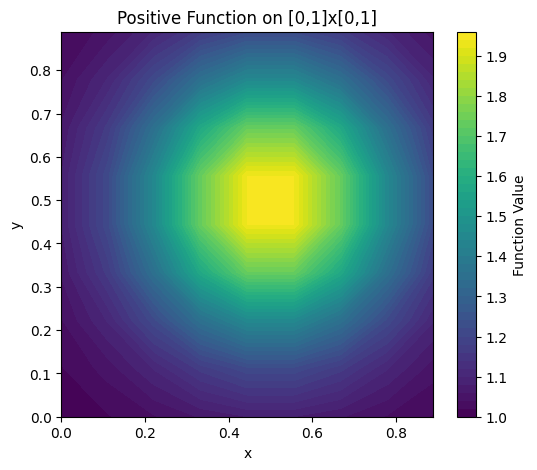

tensor(9.6516e-13)


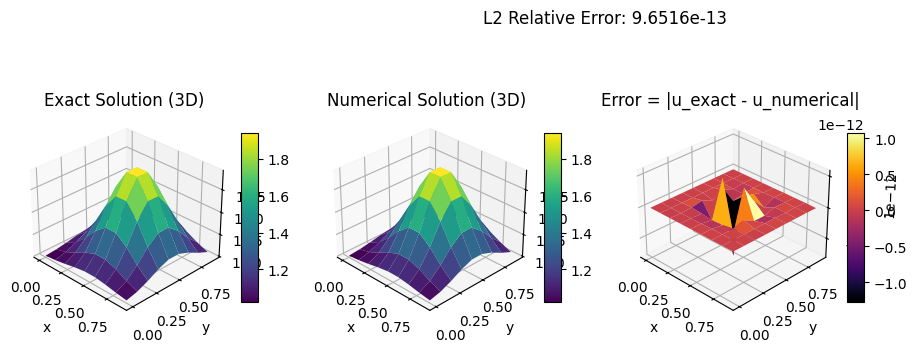

In [3]:

import matplotlib.pyplot as plt

# Define a positive function (e.g., Gaussian-like function)
Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A shifted Gaussian function to ensure positivity
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)

# Flatten the function values
gamma_exact = Gamma.flatten()
Lambda_g = forward_map_gamma_to_flux(gamma_exact)
gamma_0 = torch.ones((N, N), device = device)

gamma_0 = gamma_0.to(device)
Lambda_g = Lambda_g.to(device)


# Plot for visualization
plt.figure(figsize=(6, 5))
plt.contourf(X.cpu(), Y.cpu(), Gamma.cpu(), levels=50, cmap="viridis")
plt.colorbar(label="Function Value")
plt.title("Positive Function on [0,1]x[0,1]")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


gamma_comp = newton_method_for_F(Lambda_g, gamma_0, forward_map_gamma_to_flux, lambda_reg=0.0, learning_rate=1.0, max_iter=100, tol=1e-16)


l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)
print(l2_error)


X_np = X.numpy()
Y_np = Y.numpy()

u_exact_np = Gamma.numpy()
u_numerical_np = gamma_comp.numpy()
error = gamma_comp - Gamma
error_np = error.numpy()
l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)

fig = plt.figure(figsize=(12, 4))

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_exact_np, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Exact Solution (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

# 3D plot of Numerical Solution
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, u_numerical_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Numerical Solution (3D)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
ax2.view_init(elev=30, azim=-45)

# 3D plot of Error
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
surf3 = ax3.plot_surface(X_np, Y_np, error_np, cmap="inferno", linewidth=0, antialiased=True)
ax3.set_title("Error = |u_exact - u_numerical|")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)
ax3.view_init(elev=30, azim=-45)

# # 3D plot of Exact Solution
# ax1 = fig.add_subplot(1, 4,4, projection='3d')
# surf1 = ax1.plot_surface(X_np, Y_np, u_numerical_2, cmap="viridis", linewidth=0, antialiased=True)
# ax1.set_title("Numerical Solution 2 (3D)")
# ax1.set_xlabel('x')
# ax1.set_ylabel('y')
# fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# # Adjust viewing angle so that (1,1) is more towards the front
# ax1.view_init(elev=30, azim=-45)
# 
# ax3.set_ylim(1, 0)
# ax2.set_ylim(1, 0)
# ax1.set_ylim(1, 0)

plt.suptitle(f"L2 Relative Error: {l2_error:.4e}")
plt.tight_layout()
plt.show()

In [4]:

def classical_newton_method_gen_data(Lambda_g_flat, gamma_0_flat, forward_map_gamma_to_flux, lambda_reg, learning_rate, max_iter):
    gamma_n = gamma_0_flat.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((max_iter + 1, gamma_0_flat.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = gamma_n.view(-1)  # Store the flattened solution
    
    for i in range(max_iter):
        # Solve the Newton iteration
        F_n = forward_map_gamma_to_flux(gamma_n) - Lambda_g_flat
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_n).detach()
        
        # Move or ensure DF_n is on GPU
        DF_n = DF_n.to(device)
        F_n = F_n.to(device)
        
        A = DF_n.T @ DF_n + lambda_reg * torch.eye(N * N, device=device, dtype=DF_n.dtype)
        b = - DF_n.T @ F_n
        
        delta_gamma = torch.linalg.solve(A.detach(), b.detach())
        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += learning_rate * delta_gamma.squeeze()

        # Store the current solution in the matrix
        solutions_matrix[i + 1, :] = gamma_n.view(-1)  # Store the flattened solution

    return solutions_matrix



def inverse_map_sparse_cholesky(gama_realizations, lambda_reg, Perm, sparsity):
    M = gama_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        gamma_i = gama_realizations[i, :]  # ith function
        
         # Solve the Newton iteration
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_i).detach()
        
        # Move or ensure DF_n is on GPU
        DF_n = DF_n.to(device)
        
        A_i = DF_n.T @ DF_n + lambda_reg * torch.eye(N * N, device=device, dtype=DF_n.dtype)
           
        # Compute the inverse using Cholesky decomposition
        U_sparse = sparse_cholesky(A_i, Perm, sparsity)
        sparse_elements = U_sparse._values()

        # Store the flatten inverses
        flattened_inverses.append(sparse_elements)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses




# Cross-validation with GP kernel and alpha optimization using KFold
def cross_validation_loss(model, X, y, num_folds=5):
    kf = KFold(n_splits=num_folds)
    l2_losses = 0

    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # GP prediction on validation data
        model.fit(X_train, y_train)
        y_pred_val = model(X_val)

        # Compute the relative L2 loss
        l2_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) / torch.norm(y_val, dim=1))
        l2_losses += l2_loss

    # Return the mean loss across all folds
    return l2_losses / num_folds


# Train step
def train_step(model, X, y, optimizer):
    optimizer.zero_grad()
    loss_value = cross_validation_loss(model, X, y, num_folds)
    loss_value.backward()
    optimizer.step()
    return loss_value


def periodic_kernel(X1, X2, length_scale=1, period=1):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    sine_term = torch.sin(torch.pi * pairwise_dists / period)
    K = torch.exp(-2 * sine_term ** 2 / length_scale ** 2)
    return K


# Define the kernel function
def matern_kernel(X1, X2, length_scale):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists / length_scale
    K = (1 + scale) * torch.exp(-scale)
    return K


In [5]:
# Instantiate the GP model and Adam optimizer
optimizer = [None] * 2
gp_model = [None] * 2

# Generate data for f and u based on GP(0, K)
f_realizations, u_realizations = generate_f_u_from_gp(num_realizations, N, periodic_kernel, length_scale=0.2)

# Solve the system for each realization with up to max_iter Newton iterations.
v_solutions = torch.cat(
    [classical_newton_method_gen_data(f_realizations[j], u_realizations[j], forward_map_gamma_to_flux, lambda_reg = 0.0, learning_rate=1, max_iter=num_newton_iter)
     for j in range(num_realizations)], dim=0)


f = torch.repeat_interleave(f_realizations, repeats=num_newton_iter, dim=0)
X_data = v_solutions

# lambda_reg = 1e-5
lambda_reg = 1e-10

# y_data_groundtruth = inverse_map_tri(v_solutions, N, lambda_reg)
y_data = inverse_map_sparse_cholesky(v_solutions, lambda_reg, Perm, sparsity)


/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/pyKoLesky/cholesky.py:59: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  sparse_cholesky = torch.sparse_coo_tensor(indices, data, size=(n, n))


# Learn the data using sklearn GP

In [6]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Ndata, m = X_data.shape
# _, p = y_data.shape
#
# kernel = C(1.0, (1e-3, 1e3)) * \
#          RBF(length_scale=np.ones(X_data.shape[1]), length_scale_bounds=(1e-2, 1e2)) \
#          + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
#
# base_gpr = GaussianProcessRegressor(
#     kernel=kernel,
#     n_restarts_optimizer=10,
#     normalize_y=True
# )
#
# # Wrap in MultiOutputRegressor to fit one GP per output
# multi_gpr = MultiOutputRegressor(base_gpr)
# multi_gpr.fit(X_data, y_data)

# Instantiate the GP model and Adam optimizer
multi_gpr = GaussianProcess(length_scale=1.0)
multi_gpr_optimizer = optim.Adam(multi_gpr.parameters(), lr=0.01)


train_loss_history = []
test_rl2_history = []

for step in range(1000):
    loss_value = train_step(multi_gpr, X_data[:num_training], y_data[:num_training], multi_gpr_optimizer)
    print(f"step: {step}, loss: {loss_value}")

step: 0, loss: 0.0745068196763606
step: 1, loss: 0.0736978772436024
step: 2, loss: 0.07288951831516874
step: 3, loss: 0.07208182308963106
step: 4, loss: 0.07127487946667824
step: 5, loss: 0.07046878303644041
step: 6, loss: 0.06966363710811234
step: 7, loss: 0.06885955271149917
step: 8, loss: 0.06805664863857361
step: 9, loss: 0.06725505146406871
step: 10, loss: 0.06645489555358937
step: 11, loss: 0.06565632305074418
step: 12, loss: 0.06485948377832848
step: 13, loss: 0.06406453509947457
step: 14, loss: 0.06327164174368108
step: 15, loss: 0.062480975611213095
step: 16, loss: 0.061692715749057325
step: 17, loss: 0.060907048515596064
step: 18, loss: 0.06012416808424399
step: 19, loss: 0.059344277341331894
step: 20, loss: 0.058567588988618136
step: 21, loss: 0.0577943267452055
step: 22, loss: 0.05702472611358346
step: 23, loss: 0.056259034258920905
step: 24, loss: 0.055497508382762996
step: 25, loss: 0.05474041207866739
step: 26, loss: 0.05398800961718091
step: 27, loss: 0.0532405586709026

Step 0, Loss: 0.0745068196763606, Rel. L2 err: 0.05338682518381452, L2 err: 20.749574330551724, L2 Pred Inv: 372.62944950896383, L2 Comp Inv: 387.85852609824707, Learning Rate: 0.01, Lambda = 1e-10
Step 1, Loss: 0.0736978772436024, Rel. L2 err: 0.05273935184711667, L2 err: 20.497890117703456, L2 Pred Inv: 372.86902064157, L2 Comp Inv: 387.85852609824707, Learning Rate: 0.01, Lambda = 1e-10
Step 2, Loss: 0.07288951831516874, Rel. L2 err: 0.05209441771864896, L2 err: 20.247188668434212, L2 Pred Inv: 373.10731138969214, L2 Comp Inv: 387.85852609824707, Learning Rate: 0.01, Lambda = 1e-10
Step 3, Loss: 0.07208182308963106, Rel. L2 err: 0.05145203341959375, L2 err: 19.997474059370933, L2 Pred Inv: 373.3442773198555, L2 Comp Inv: 387.85852609824707, Learning Rate: 0.01, Lambda = 1e-10
Step 4, Loss: 0.07127487946667824, Rel. L2 err: 0.05081223407283212, L2 err: 19.748759970531175, L2 Pred Inv: 373.57987299679235, L2 Comp Inv: 387.85852609824707, Learning Rate: 0.01, Lambda = 1e-10
Step 5, Los

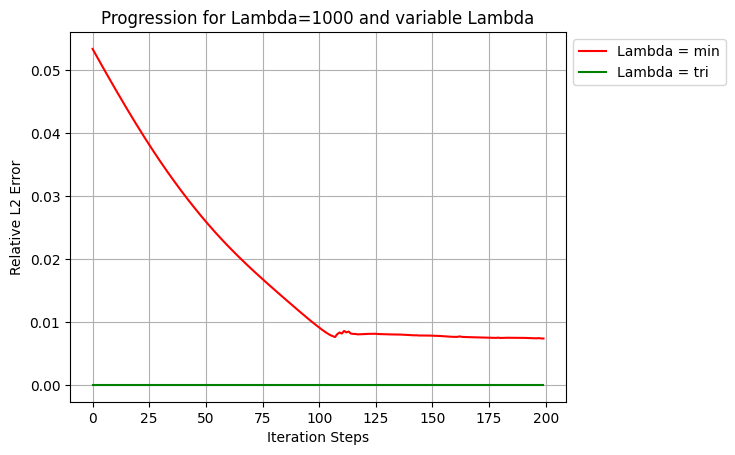

In [7]:
# Train the model using Adam and cross-validation
num_steps = 200  # Number of optimization steps
# Define a matrix containing the lambda values and the corresponding cross-validation error
alpha_error_matrix = torch.zeros((2, num_steps))


# Instantiate the GP model and Adam optimizer
gp_model[0] = GaussianProcess(length_scale=1.0)
optimizer[0] = optim.Adam(gp_model[0].parameters(), lr=0.01)


train_loss_history = []
test_rl2_history = []

for step in range(num_steps):
    loss_value = train_step(gp_model[0], X_data[:num_training], y_data[:num_training], optimizer[0])

    # Step the schedulerloss_value
    # scheduler.step(loss_value)

    # Predict on the test set
    X_train = X_data[:num_training]
    y_train = y_data[:num_training]
    X_test = X_data[num_training:]
    y_pred_test = y_data[num_training:]

    with torch.no_grad():
        gp_model[0].fit(X_train, y_train)
        y_pred_test_pca = gp_model[0](X_test)

    # Calculate relative L2 error
    rl2error = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    # r2error_A_inv = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    l2error = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1)).item()
    l2error_pred_inverse = torch.mean(torch.norm(y_pred_test_pca, dim=1)).item()
    l2error_comp_inverse = torch.mean(torch.norm(y_pred_test, dim=1)).item()

    current_lr = optimizer[0].param_groups[0]['lr']
    alpha_error_matrix[0, step] = rl2error

    train_loss_history.append(loss_value.item())
    test_rl2_history.append(rl2error)

    print(
        f"Step {step}, Loss: {loss_value.item()}, Rel. L2 err: {rl2error}, L2 err: {l2error}, L2 Pred Inv: {l2error_pred_inverse}, L2 Comp Inv: {l2error_comp_inverse}, Learning Rate: {current_lr}, Lambda = {lambda_reg}")


# # After training, save each model's state_dict with a unique filename
# torch.save(gp_model[0].state_dict(), f"gaussian_process_model_min.pth")
# torch.save(gp_model[1].state_dict(), f"gaussian_process_model_tri.pth")

# # After training, save each model's state_dict with a unique filename
# torch.save(gp_model[0].state_dict(), f"gaussian_process_model_lambda_L_inv.pth")
# torch.save(gp_model[1].state_dict(), f"gaussian_process_model_lambda_A_inv.pth")


# Plotting
def plot_results(matrix, num_steps):
    # Convert matrix to numpy for easier plotting
    result_numpy = matrix.numpy()

    # Define a list of colors for each alpha (7 values, 7 colors)
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Red, Green, Blue, Cyan, Magenta, Yellow, Black

    # Plot for each alpha
    plt.plot(range(num_steps), result_numpy[0, :], label=f'Lambda = min', color=colors[0])
    plt.plot(range(num_steps), result_numpy[1, :], label=f'Lambda = tri', color=colors[1])

    # Add labels and legend
    plt.xlabel('Iteration Steps')
    plt.ylabel('Relative L2 Error')
    plt.title('Progression for Lambda=1000 and variable Lambda')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()


# Call the plot function
plot_results(alpha_error_matrix, num_steps)

# Generating Testing Data

In [8]:
import torch

gammas_flat  = []
lambdas_flat = []

with torch.no_grad():
    for gamma in X_data:                     # X_data: iterable or tensor [N, ...]
        Lambda = forward_map_gamma_to_flux(gamma)
        gammas_flat.append(gamma.reshape(-1))    # flatten γᵢ
        lambdas_flat.append(Lambda.reshape(-1))  # flatten Λᵢ

Gamma_mat_  = torch.stack(gammas_flat,  dim=0)    # [N, D_gamma]
Lambda_mat_ = torch.stack(lambdas_flat, dim=0)    # [N, D_lambda]

torch.save({"Lambda": Lambda_mat_, "Gamma": Gamma_mat_}, "./data/CalderonTraining.pt")

# 1) Load saved matrices (each row is a flattened sample)
payload = torch.load("./data/CalderonTraining.pt", map_location="cpu")
Gamma_loaded  = payload["Gamma"]   # [N, D_gamma]
Lambda_loaded = payload["Lambda"]  # [N, D_lambda]

print(Gamma_mat_.shape, Lambda_mat_.shape)

eps_ = 1e-12

# Global relative Frobenius errors
gamma_relF  = torch.norm(Gamma_loaded - Gamma_mat_)  / (torch.norm(Gamma_mat_)  + eps_)
lambda_relF = torch.norm(Lambda_loaded - Lambda_mat_) / (torch.norm(Lambda_mat_) + eps_)

print(f"Gamma global rel Frobenius:  {gamma_relF:.3e}")
print(f"Lambda global rel Frobenius: {lambda_relF:.3e}")


torch.Size([11000, 81]) torch.Size([11000, 1024])
Gamma global rel Frobenius:  0.000e+00
Lambda global rel Frobenius: 0.000e+00


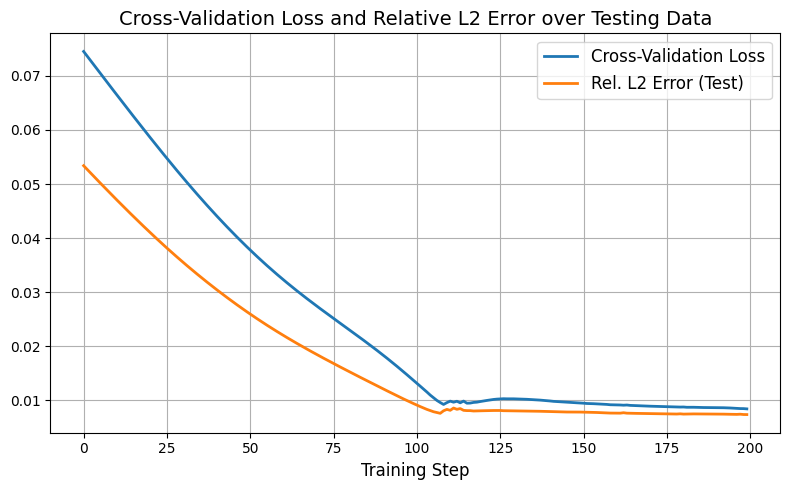

In [9]:
# === Plotting ===
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Cross-Validation Loss', linewidth=2)
plt.plot(test_rl2_history, label='Rel. L2 Error (Test)', linewidth=2)

plt.xlabel("Training Step", fontsize=12)
# plt.ylabel("Value", fontsize=12)
plt.title("Cross-Validation Loss and Relative L2 Error over Testing Data", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
# Save to result folder
plt.savefig('./result/training_history.png', dpi=300, bbox_inches='tight')
# Optional: Display
plt.show()

In [10]:
def deep_newton_method_sparse_cholesky(model, N, f, v0, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        U_sparse = model.forward(X_train)

        # Convert sparse tensor to dense for validation
        nonzeros_indices = non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  # Evaluate F at current guess

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n

def Deep_Newton(model, Lambda_g, gamma_0, forward_map_gamma_to_flux, lambda_reg, learning_rate, max_iter, c1, beta, tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    gamma_n = gamma_n.detach()
    
    for i in range(max_iter):
        
        # Prepare the inputs for GP prediction
        X_train = gamma_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad(): # Disable gradients for inference
            U_sparse = model.forward(X_train)
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices = non_zeros(N*N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N*N, N*N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        # Solve the Newton iteration
        F_n = forward_map_gamma_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_n).detach()
        
        # Compute the right-hand side of the linear system
        d = - DF_n.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        delta_gamma = A_inv @ d

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma 
        F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g
        # 
        # # Stricter Armijo Rules
        # # while torch.norm(F_n_delta)**2 >= (1 - c1) * torch.norm(F_n)**2:
        # #     alpha *= beta
        # # Modify the Backtracking Logic
        # # while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 + c1 * alpha * torch.norm(delta_gamma)**2
        # # Adaptive Line Search Strategy
        # # alpha = max(learning_rate, alpha * beta)
        # # Normalize the Gradient Dot Product
        # # scaled_dot_product = torch.dot(d, delta_gamma) / (torch.norm(d) * torch.norm(delta_gamma))
        # 
        while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 +  2*c1 * alpha * torch.dot(d, delta_gamma):
            alpha *= beta  # Reduce step size
            gamma_trial = gamma_n + alpha * delta_gamma 
            F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g
        
        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)
        
    gamma = gamma_n.reshape(N, N)
    return gamma

In [11]:
def Deep_Newton_rl2_history(model, Lambda_g, gamma_0, gamma_truth, forward_map_gamma_to_flux, lambda_reg, learning_rate, max_iter, c1, beta, tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    gamma_n = gamma_n.detach()

    rl2_history = []

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = gamma_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad(): # Disable gradients for inference
            U_sparse = model.forward(X_train)

        # Convert sparse tensor to dense for validation
        nonzeros_indices = non_zeros(N*N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N*N, N*N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        # Solve the Newton iteration
        F_n = forward_map_gamma_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_n).detach()

        # Compute the right-hand side of the linear system
        d = - DF_n.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        delta_gamma = A_inv @ d

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma
        F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g
        #
        # # Stricter Armijo Rules
        # # while torch.norm(F_n_delta)**2 >= (1 - c1) * torch.norm(F_n)**2:
        # #     alpha *= beta
        # # Modify the Backtracking Logic
        # # while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 + c1 * alpha * torch.norm(delta_gamma)**2
        # # Adaptive Line Search Strategy
        # # alpha = max(learning_rate, alpha * beta)
        # # Normalize the Gradient Dot Product
        # # scaled_dot_product = torch.dot(d, delta_gamma) / (torch.norm(d) * torch.norm(delta_gamma))
        #
        while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 +  2*c1 * alpha * torch.dot(d, delta_gamma):
            alpha *= beta  # Reduce step size
            gamma_trial = gamma_n + alpha * delta_gamma
            F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g

        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)

        rl2_history.append(torch.linalg.norm(gamma_n - gamma_truth) / torch.linalg.norm(gamma_truth))

    gamma = gamma_n.reshape(N, N)
    return gamma, rl2_history

In [27]:
num_times = 10 
times = torch.empty(num_times)
for i in range(num_times):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = gp_model[0].forward(torch.rand(1,81))
    times[i] = time.perf_counter()-t0
print("times\n%s"%str(times))
print("times.median(): %.1e"%times.median())

times
tensor([0.0030, 0.0023, 0.0022, 0.0022, 0.0022, 0.0021, 0.0035, 0.0024, 0.0022,
        0.0022])
times.median(): 2.2e-03


In [12]:

# Generating Solutions using the GP sampled data
num_test_data = 200

Lambda_g, gamma_realizations = generate_f_u_from_gp(num_test_data, N, periodic_kernel, length_scale=0.2)
v_vals2 = gamma_realizations
f_vals1 = torch.cat([(forward_map_gamma_to_flux(gamma_realizations[i, :])).unsqueeze(0)
                     for i in range(gamma_realizations.size(0))], dim=0)

gamma_solutions = v_vals2[:, ::1]
Lambda_g_realizations = f_vals1[:, ::1]
gamma_01 = torch.ones_like(gamma_solutions[0])  # Initial guess v0

# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0


# Loop through each realization
rl2_histories = []

for j in range(num_test_data):
    
    # Initial guess with relative error
    relative_error = 0.03
    Gamma = gamma_solutions[j, :]
    mean_gamma1 = torch.mean(Gamma)  # Average value of Gamma2
    noise_std1 = relative_error * mean_gamma1  # Standard deviation of noise
    noise1 = torch.randn_like(Gamma) * noise_std1 # Add Gaussian noise with calculated standard deviation
    gamma_0 = Gamma + noise1
    gamma_0 = torch.clamp(gamma_0, min=0.0) # Ensure Gamma2_noisy remains positive

    gamma_pre, rl2_history = Deep_Newton_rl2_history(gp_model[0], Lambda_g_realizations[j, :], gamma_0, Gamma, forward_map_gamma_to_flux, lambda_reg, learning_rate = 1, max_iter = 1500, c1=1e-4, beta=0.3, tol=1e-6)
    gamma_predict = gamma_pre.flatten()

    rl2_histories.append(rl2_history)

    # gamma_comp = newton_method_for_F(Lambda_g_realizations[j, :], gamma_0, forward_map_gamma_to_flux, lambda_reg=0.00001, learning_rate=1.0, max_iter=1000, tol=1e-16)
    # gamma_com = gamma_comp.flatten()

    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(Gamma - gamma_predict) / torch.norm(Gamma))
    # l2error = (torch.norm(Gamma - gamma_0) / torch.norm(Gamma))
    l2error = torch.norm(Gamma - gamma_predict)
    
    print(f"{j}, Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

    # Calculate the squared relative L2 error for the current realization
    rl2error = rl2error ** 2
    l2error = l2error ** 2

    # Accumulate the error
    relative_error_sum += rl2error.item()
    error_sum += l2error.item()

rl2_histories_plot = torch.stack([torch.stack(row, dim=0) for row in rl2_histories], dim=0)

# Calculate the mean relative error by dividing by the number of realizations
mean_relative_error = relative_error_sum / num_test_data
mean_error = error_sum / num_test_data

# Take the square root
sqrt_mean_relative_error = mean_relative_error ** 0.5
sqrt_mean_error = mean_error ** 0.5

print(f"Total Rel. L2 err: {mean_relative_error}, Total L2 err: {mean_error}, Lambda = {lambda_reg}")
print(f"Total Rel. L2 err: {mean_relative_error ** 4}, Total L2 err: {mean_error}, Lambda = {lambda_reg}")


0, Total Rel. L2 err: 1.010477676602229e-12, Total L2 err: 2.0768197584104235e-11
1, Total Rel. L2 err: 1.1292379191558336e-12, Total L2 err: 1.2359562185241609e-11
2, Total Rel. L2 err: 1.9364013038587697e-12, Total L2 err: 5.0034126242059567e-11
3, Total Rel. L2 err: 1.7417653331692103e-13, Total L2 err: 9.77992620348302e-13
4, Total Rel. L2 err: 2.1452430691068975e-12, Total L2 err: 3.999924164612887e-11
5, Total Rel. L2 err: 1.9750275847761987e-13, Total L2 err: 6.571641562712146e-13
6, Total Rel. L2 err: 3.4738829016482184e-13, Total L2 err: 1.508563006976436e-12
7, Total Rel. L2 err: 2.1326173906709146e-13, Total L2 err: 5.503351456158243e-13
8, Total Rel. L2 err: 1.673936899659834e-13, Total L2 err: 4.448781655670064e-13
9, Total Rel. L2 err: 5.819933680085343e-14, Total L2 err: 7.64251777995054e-14
10, Total Rel. L2 err: 2.740422009450015e-12, Total L2 err: 1.2805423018379804e-10
11, Total Rel. L2 err: 3.0557619088869068e-12, Total L2 err: 9.473139880628688e-11
12, Total Rel. L

In [13]:
import torch

gammas_flat  = []
lambdas_flat = []

with torch.no_grad():
    for gamma in gamma_solutions:                     # X_data: iterable or tensor [N, ...]
        Lambda = forward_map_gamma_to_flux(gamma)
        gammas_flat.append(gamma.reshape(-1))    # flatten γᵢ
        lambdas_flat.append(Lambda.reshape(-1))  # flatten Λᵢ

Gamma_mat_  = torch.stack(gammas_flat,  dim=0)    # [N, D_gamma]
Lambda_mat_ = torch.stack(lambdas_flat, dim=0)    # [N, D_lambda]

torch.save({"Lambda": Lambda_mat_, "Gamma": Gamma_mat_}, "./data/CalderonTesting.pt")

# 1) Load saved matrices (each row is a flattened sample)
payload = torch.load("./data/CalderonTesting.pt", map_location="cpu")
Gamma_loaded  = payload["Gamma"]   # [N, D_gamma]
Lambda_loaded = payload["Lambda"]  # [N, D_lambda]

eps_ = 1e-12

print(Lambda_mat_.shape, Gamma_mat_.shape)
# Global relative Frobenius errors
gamma_relF  = torch.norm(Gamma_loaded - Gamma_mat_)  / (torch.norm(Gamma_mat_)  + eps_)
lambda_relF = torch.norm(Lambda_loaded - Lambda_mat_) / (torch.norm(Lambda_mat_) + eps_)

print(f"Gamma global rel Frobenius:  {gamma_relF:.3e}")
print(f"Lambda global rel Frobenius: {lambda_relF:.3e}")

torch.Size([200, 1024]) torch.Size([200, 81])
Gamma global rel Frobenius:  0.000e+00
Lambda global rel Frobenius: 0.000e+00


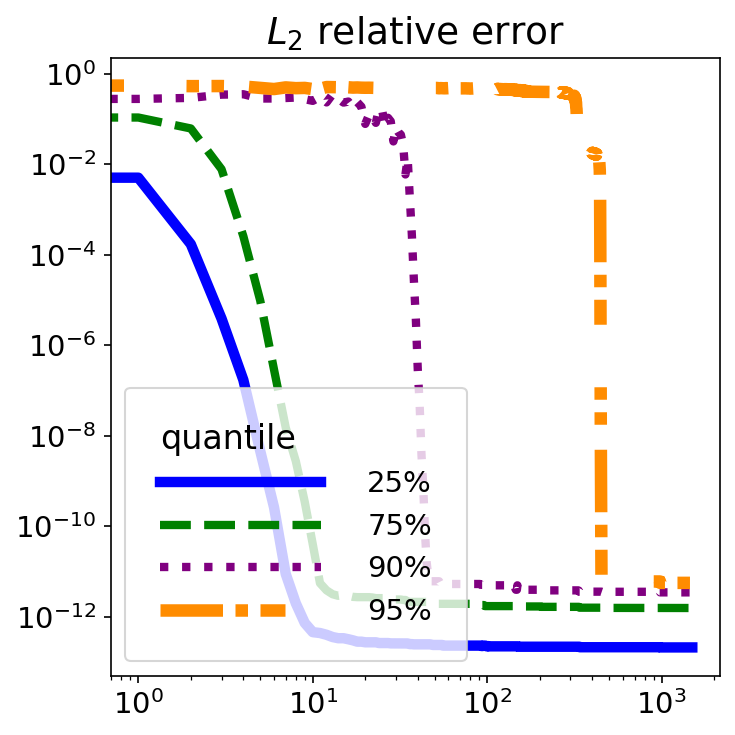

In [14]:
import matplotlib.pyplot as plt
import torch

quantiles = [0.25, 0.75, 0.9, 0.95]

# Compute quantile curves over samples (dim=0)
quantile_curves = torch.quantile(rl2_histories_plot, torch.tensor(quantiles), dim=0)

# Appearance settings to match first figure
plt.figure(figsize=(5, 5), dpi=150)
x = torch.arange(rl2_histories_plot.shape[-1])

# Updated line styles and widths
styles = [
    {'color': 'blue',       'linestyle': '-',                  'linewidth': 5, 'label': '25%'},
    {'color': 'green',      'linestyle': '--',                 'linewidth': 4, 'label': '75%'},
    {'color': 'purple',     'linestyle': ':',                  'linewidth': 4, 'label': '90%'},
    {'color': 'darkorange', 'linestyle': (0, (5, 1, 1, 1, 2)),   'linewidth': 6, 'label': '95%'}  # thicker and more spaced
]

for i, style in enumerate(styles):
    plt.plot(x, quantile_curves[i].numpy(), **style)

# Axis settings
plt.xscale('log')
plt.yscale('log')
plt.title(r'$L_2$ relative error', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend settings
legend = plt.legend(
    title='quantile',
    fontsize=14,
    title_fontsize=16,
    loc='lower left',
    handlelength=5.5,
    handletextpad=1.6,
    borderpad=1.2,
)
legend._legend_box.align = "left"

plt.grid(False)
plt.tight_layout()
plt.savefig("./result/l2_relative_error_quantiles.png", bbox_inches='tight')
plt.show()

In [15]:
# Median of final-step errors across samples
median_final = torch.median(rl2_histories_plot[:, -1]).item()
print(f"Median final L2 error: {median_final:.6g}")

Median final L2 error: 4.81318e-13


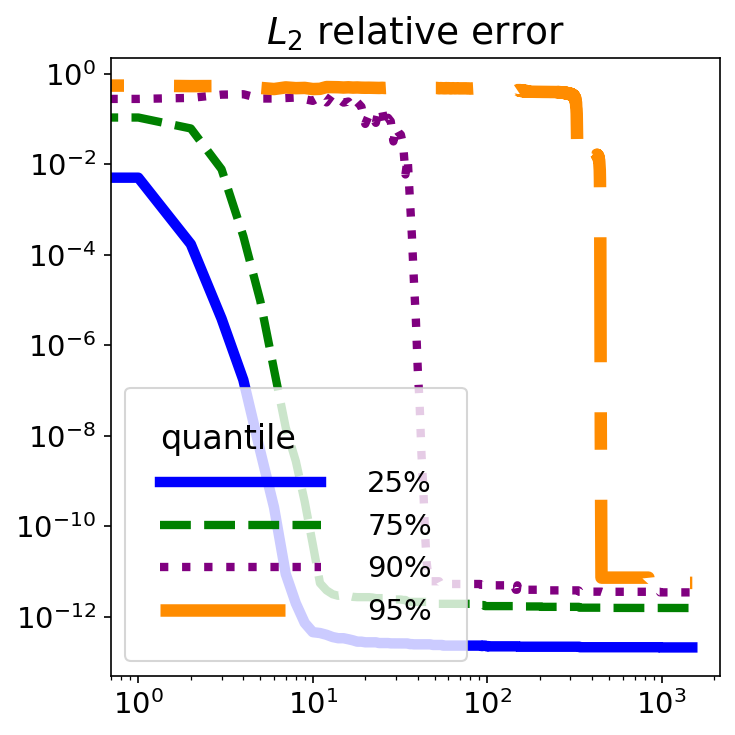

In [16]:
import matplotlib.pyplot as plt
import torch

quantiles = [0.25, 0.75, 0.9, 0.95]

# Compute quantile curves over samples (dim=0)
quantile_curves = torch.quantile(rl2_histories_plot, torch.tensor(quantiles), dim=0)

# Appearance settings to match first figure
plt.figure(figsize=(5, 5), dpi=150)
x = torch.arange(rl2_histories_plot.shape[-1])

# Updated line styles and widths
styles = [
    {'color': 'blue',       'linestyle': '-',                  'linewidth': 5, 'label': '25%'},
    {'color': 'green',      'linestyle': '--',                 'linewidth': 4, 'label': '75%'},
    {'color': 'purple',     'linestyle': ':',                  'linewidth': 4, 'label': '90%'},
    {'color': 'darkorange', 'linestyle': (0, (10, 4, 3, 4)),   'linewidth': 6, 'label': '95%'}  # thicker and more spaced
]

for i, style in enumerate(styles):
    plt.plot(x, quantile_curves[i].numpy(), **style)

# Axis settings
plt.xscale('log')
plt.yscale('log')
plt.title(r'$L_2$ relative error', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend settings
legend = plt.legend(
    title='quantile',
    fontsize=14,
    title_fontsize=16,
    loc='lower left',
    handlelength=5.5,
    handletextpad=1.6,
    borderpad=1.2,
)
legend._legend_box.align = "left"

plt.grid(False)
plt.tight_layout()
plt.savefig("./result/l2_relative_error_quantiles.png", bbox_inches='tight')
plt.show()


In [17]:
import torch

# rl2_histories_plot: shape [num_runs, T]
# e.g., rl2_histories_plot = torch.stack(list_of_runs)  # each run length T

# Choose the five quantiles:
qs = torch.tensor([0.25, 0.75, 0.90, 0.95])  # qll, ql, qm, qh, qhh (dim=0 = runs)
qll, ql, qh, qhh = torch.quantile(rl2_histories_plot, qs, dim=0)

# Save everything you need to plot later
to_save = {
    "qll": qll, "ql": ql, "qh": qh, "qhh": qhh,
    "T": rl2_histories_plot.shape[-1]
}
torch.save(to_save, "./result/calderon_l2_relative_error_quantiles.pt")
print("Saved quantiles to calderon_error_quantiles.pt")

Saved quantiles to calderon_error_quantiles.pt


In [18]:
def Deep_Newton_Seq(model, Lambda_g, gamma_0, forward_map_gamma_to_flux, lambda_reg, learning_rate, max_iter, c1, beta, tol=1e-6):
    gamma_0_flat = gamma_0.flatten()
    gamma_n = gamma_0_flat.clone()
    gamma_n = gamma_n.detach()

    gamma_history = []

    for i in range(max_iter):

        # Prepare the inputs for GP prediction
        X_train = gamma_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad(): # Disable gradients for inference
            U_sparse = model.forward(X_train)

        # Convert sparse tensor to dense for validation
        nonzeros_indices = non_zeros(N*N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N*N, N*N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        # Solve the Newton iteration
        F_n = forward_map_gamma_to_flux(gamma_n) - Lambda_g
        DF_n = torch.func.jacfwd(forward_map_gamma_to_flux)(gamma_n).detach()

        # Compute the right-hand side of the linear system
        d = - DF_n.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        delta_gamma = A_inv @ d

        alpha = learning_rate  # Initial step size
        gamma_trial = gamma_n + alpha * delta_gamma
        F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g

        while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 +  2*c1 * alpha * torch.dot(d, delta_gamma):
            alpha *= beta  # Reduce step size
            gamma_trial = gamma_n + alpha * delta_gamma
            F_n_delta = forward_map_gamma_to_flux(gamma_trial) - Lambda_g

        # Update rule: v_{n+1} = v_n + delta_v
        gamma_n += alpha * delta_gamma.squeeze()
        # if i % 100 == 0:  # Check if i is divisible by 100
        #     print(alpha)

        gamma_history.append(gamma_n.reshape(N, N).detach().clone())

    gamma = gamma_n.reshape(N, N)
    return gamma, gamma_history

tensor(2.5016e-12)


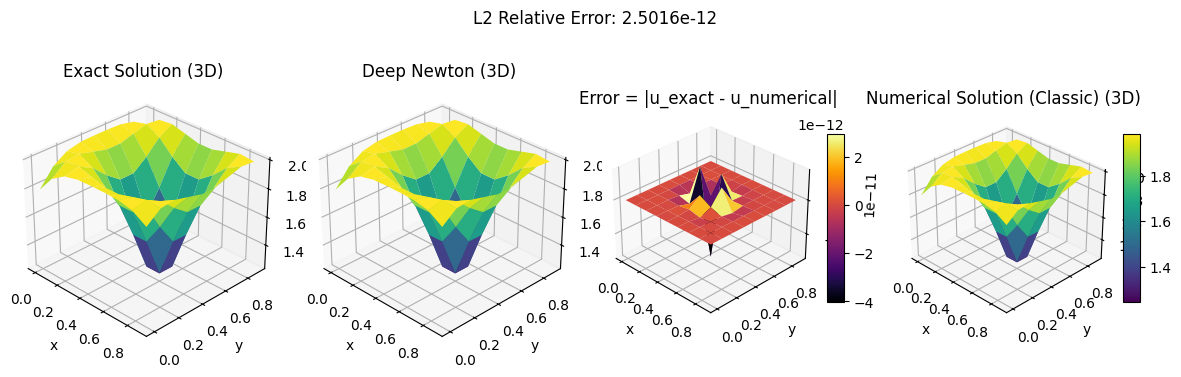

In [19]:

import matplotlib.pyplot as plt


# Define a positive function (e.g., Gaussian-like function)
# Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)
# Gamma = 1.0 + 0.5 * torch.sin(2 * torch.pi * X) * torch.sin(2 * torch.pi * Y)
# Gamma = 1.0 + torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.2)
# Gamma = 1.0 + (X ** 2 + Y ** 2)
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.exp(-Y)
# Gamma = 1.0 + torch.abs(torch.sin(torch.pi * X) + torch.cos(torch.pi * Y))
Gamma = 1.0 + torch.sin(torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2) * 1 * torch.pi)
# Gamma = 1.0 + torch.cos(((X - 0.5) ** 2 + (Y - 0.5) ** 2 ) * 1 * torch.pi)
# Gamma = 1.0 + torch.relu(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))
# Gamma = 1.0 + torch.log1p((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.abs(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))


# Flatten the function values
gamma_exact = Gamma.flatten()
Lambda_g = forward_map_gamma_to_flux(gamma_exact)
gamma_0 = torch.ones((N, N), device = device)

gamma_0 = gamma_0.to(device)
gam_0 = gamma_0.flatten()

# Initial guess with relative error
relative_error = 0.03
mean_gamma1 = torch.mean(Gamma)  # Average value of Gamma2
noise_std1 = relative_error * mean_gamma1  # Standard deviation of noise
noise1 = torch.randn_like(Gamma) * noise_std1 # Add Gaussian noise with calculated standard deviation
gamma_0 = Gamma + noise1
gamma_0 = torch.clamp(gamma_0, min=0.0) # Ensure Gamma2_noisy remains positive

Lambda_g = Lambda_g.to(device)

gamma_classic = newton_method_for_F(Lambda_g, gamma_0.flatten(), forward_map_gamma_to_flux, lambda_reg=0.0, learning_rate=1.0, max_iter=100, tol=1e-16)
gamma_comp, gamma_history = Deep_Newton_Seq(gp_model[0], Lambda_g, gamma_0.flatten(), forward_map_gamma_to_flux, lambda_reg, learning_rate = 1, max_iter = 3000, c1=1e-4, beta=0.3, tol=1e-6)


l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)
print(l2_error)


X_np = X.numpy()
Y_np = Y.numpy()

u_exact_np = Gamma.numpy()
u_numerical_np = gamma_comp.numpy()
u_classic = gamma_classic.numpy()

error = gamma_comp - Gamma
error_np = error.numpy()
l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)

fig = plt.figure(figsize=(12, 4))

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_exact_np, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Exact Solution (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
# fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

# 3D plot of Numerical Solution
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, u_numerical_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Deep Newton (3D)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
# fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
ax2.view_init(elev=30, azim=-45)

# 3D plot of Error
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
surf3 = ax3.plot_surface(X_np, Y_np, error_np, cmap="inferno", linewidth=0, antialiased=True)
ax3.set_title("Error = |u_exact - u_numerical|")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)
ax3.view_init(elev=30, azim=-45)

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4,4, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_classic, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Numerical Solution (Classic) (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

plt.suptitle(f"L2 Relative Error: {l2_error:.4e}")
plt.tight_layout()
plt.show()

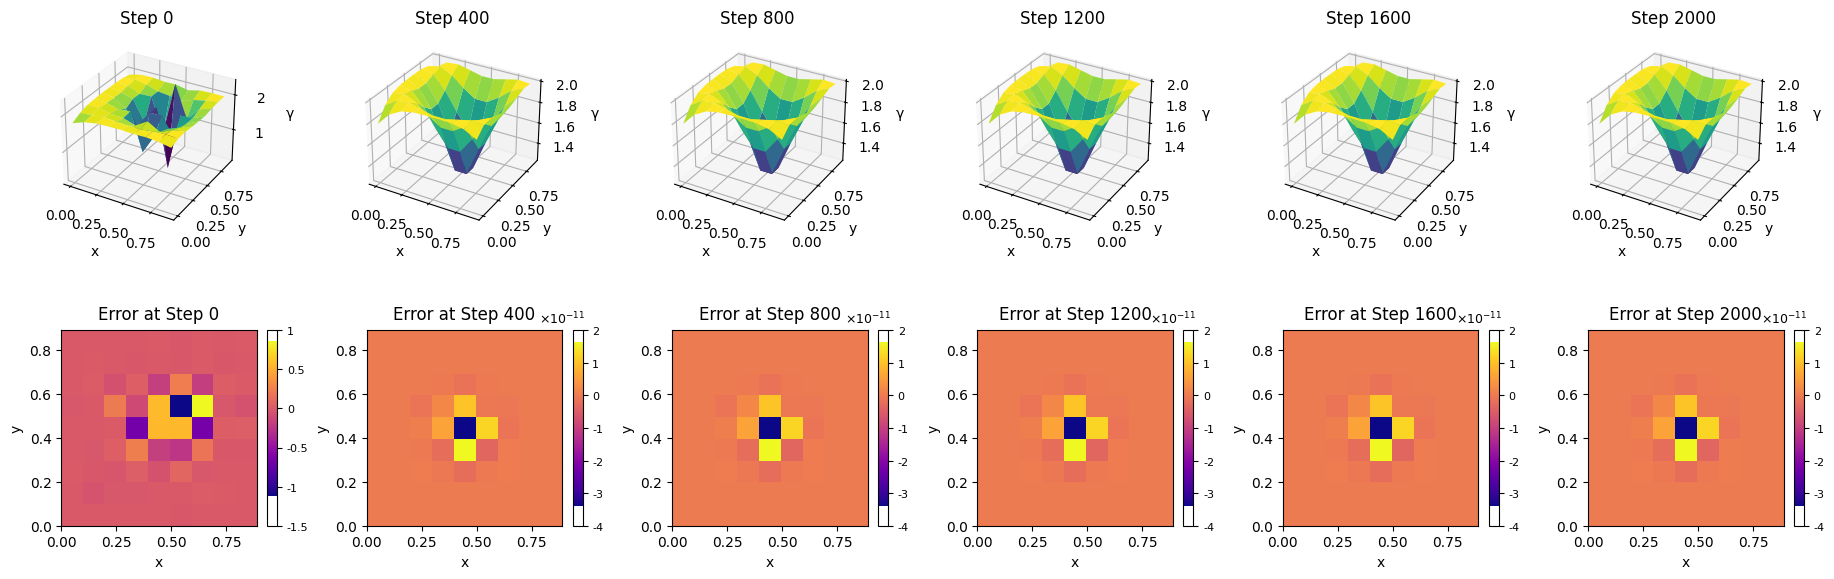

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np

plt.style.use('default')

# Select steps
num_plots = 6
total_iters = len(gamma_history)
indices = torch.linspace(0, 2000, steps=num_plots).long()

fig = plt.figure(figsize=(3.2 * num_plots, 6))

for i, idx in enumerate(indices):
    gamma_i = gamma_history[idx].numpy()
    error_i = (gamma_history[idx] - Gamma).numpy()

    # Clean any bad values
    error_i = np.nan_to_num(error_i, nan=0.0, posinf=0.0, neginf=0.0)

    # Compute scale per image
    max_abs = np.max(np.abs(error_i))
    if max_abs == 0:
        scale_exp = 0
    else:
        scale_exp = int(np.floor(np.log10(max_abs)))
    scale_factor = 10 ** scale_exp
    scaled_error = error_i / scale_factor
    scale_label = r"$\times 10^{{{}}}$".format(scale_exp)

    # --- Top Row: 3D solution plot ---
    ax1 = fig.add_subplot(2, num_plots, i + 1, projection='3d')
    ax1.plot_surface(X_np, Y_np, gamma_i, cmap='viridis', edgecolor='none', antialiased=True)
    ax1.set_title(f"Step {idx.item()}", pad=10)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('γ')
    ax1.view_init(elev=30, azim=-60)

    # --- Bottom Row: 2D error imshow ---
    ax2 = fig.add_subplot(2, num_plots, i + 1 + num_plots)
    im = ax2.imshow(scaled_error, origin='lower', cmap='plasma',
                    extent=[X_np.min(), X_np.max(), Y_np.min(), Y_np.max()])
    ax2.set_title(f"Error at Step {idx.item()}", pad=8)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')

    # Add colorbar with clean numeric ticks
    cbar = plt.colorbar(im, ax=ax2, orientation='vertical',
                        fraction=0.046, pad=0.04)
    tick_values = cbar.get_ticks()
    cbar.set_ticks(tick_values)
    cbar.set_ticklabels([f"{int(v)}" if v.is_integer() else f"{v:.1f}" for v in tick_values])
    cbar.ax.tick_params(labelsize=8)

    # Add scale label at top-right inside each subplot
    if scale_exp == 0:
        scale_label = ""
    else:
        scale_label = r"$\times 10^{{{}}}$".format(scale_exp)

    ax2.text(1.12, 1.02, scale_label,
             transform=ax2.transAxes,
             fontsize=9,
             ha='right', va='bottom')

# Final layout
plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.92, wspace=0.15, hspace=0.5)

# Save to disk
os.makedirs('./result', exist_ok=True)
plt.savefig('./result/calderon_deep_newton_gp.png',
            dpi=300, bbox_inches='tight', transparent=False)

# plt.show()  # Optional


tensor(1.3814e-12)


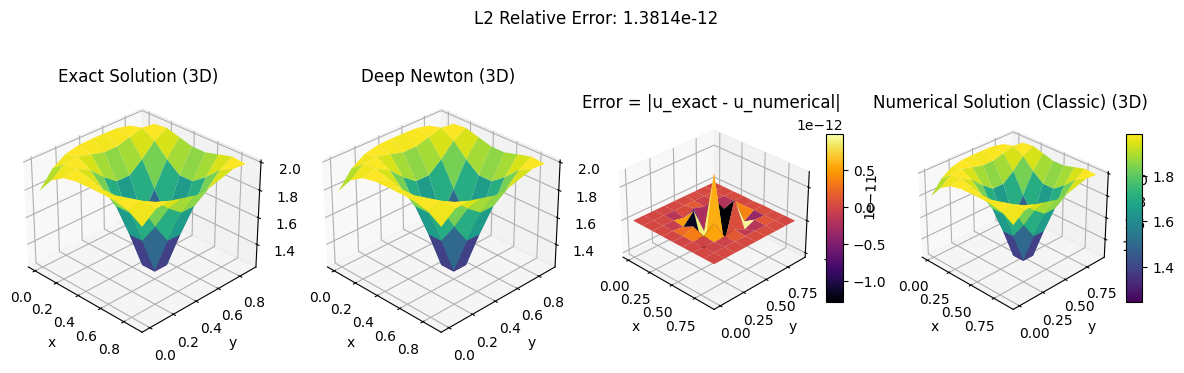

In [21]:

import matplotlib.pyplot as plt


# Define a positive function (e.g., Gaussian-like function)
# Gamma = torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.1) + 1.0  # A
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.cos(torch.pi * Y)
# Gamma = 1.0 + 0.5 * torch.sin(2 * torch.pi * X) * torch.sin(2 * torch.pi * Y)
# Gamma = 1.0 + torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.2)
# Gamma = 1.0 + (X ** 2 + Y ** 2)
# Gamma = 1.0 + torch.sin(torch.pi * X) * torch.exp(-Y)
# Gamma = 1.0 + torch.abs(torch.sin(torch.pi * X) + torch.cos(torch.pi * Y))
Gamma = 1.0 + torch.sin(torch.sqrt((X - 0.5) ** 2 + (Y - 0.5) ** 2) * 1 * torch.pi)
# Gamma = 1.0 + torch.cos(((X - 0.5) ** 2 + (Y - 0.5) ** 2 ) * 1 * torch.pi)
# Gamma = 1.0 + torch.relu(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))
# Gamma = 1.0 + torch.log1p((X - 0.5) ** 2 + (Y - 0.5) ** 2)
# Gamma = 1.0 + torch.abs(torch.sin(2 * torch.pi * X) * torch.cos(2 *torch.pi * Y))


# Flatten the function values
gamma_exact = Gamma.flatten()
Lambda_g = forward_map_gamma_to_flux(gamma_exact)
gamma_0 = torch.ones((N, N), device = device)

gamma_0 = gamma_0.to(device)
gam_0 = gamma_0.flatten()

# Initial guess with relative error
relative_error = 0.03
mean_gamma1 = torch.mean(Gamma)  # Average value of Gamma2
noise_std1 = relative_error * mean_gamma1  # Standard deviation of noise
noise1 = torch.randn_like(Gamma) * noise_std1 # Add Gaussian noise with calculated standard deviation
gamma_0 = Gamma + noise1
gamma_0 = torch.clamp(gamma_0, min=0.0) # Ensure Gamma2_noisy remains positive

Lambda_g = Lambda_g.to(device)

gamma_classic = newton_method_for_F(Lambda_g, gamma_0.flatten(), forward_map_gamma_to_flux, lambda_reg=0.0, learning_rate=1.0, max_iter=100, tol=1e-16)
gamma_comp = Deep_Newton(gp_model[0], Lambda_g, gamma_0.flatten(), forward_map_gamma_to_flux, lambda_reg, learning_rate = 1, max_iter = 3000, c1=1e-4,
                                                   beta=0.3, tol=1e-6)


l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)
print(l2_error)


X_np = X.numpy()
Y_np = Y.numpy()

u_exact_np = Gamma.numpy()
u_numerical_np = gamma_comp.numpy()
u_classic = gamma_classic.numpy()

error = gamma_comp - Gamma
error_np = error.numpy()
l2_error = torch.norm(gamma_comp - Gamma) / torch.norm(Gamma)

fig = plt.figure(figsize=(12, 4))

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_exact_np, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Exact Solution (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
# fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

# 3D plot of Numerical Solution
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, Y_np, u_numerical_np, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Deep Newton (3D)")
ax2.set_xlabel('x')
ax2.set_ylabel('y')
# fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
ax2.view_init(elev=30, azim=-45)

# 3D plot of Error
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
surf3 = ax3.plot_surface(X_np, Y_np, error_np, cmap="inferno", linewidth=0, antialiased=True)
ax3.set_title("Error = |u_exact - u_numerical|")
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)
ax3.view_init(elev=30, azim=-45)

# 3D plot of Exact Solution
ax1 = fig.add_subplot(1, 4,4, projection='3d')
surf1 = ax1.plot_surface(X_np, Y_np, u_classic, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_title("Numerical Solution (Classic) (3D)")
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
# Adjust viewing angle so that (1,1) is more towards the front
ax1.view_init(elev=30, azim=-45)

plt.suptitle(f"L2 Relative Error: {l2_error:.4e}")
plt.tight_layout()
plt.show()